# Loading and setting up the data

In [1]:
from google.colab import drive
import h5py
import numpy as np
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
drive_path = '/content/drive/MyDrive/Astro Projects/Galaxy morphology/data/Galaxy10_DECals.h5'
local_path = '/content/Galaxy10_DECals.h5'

if not os.path.exists(local_path):
    print("Copying dataset to local VM disk...")
    !cp "{drive_path}" "{local_path}"
    print("Transfer complete.")

print("Loading dataset into RAM safely...")
with h5py.File(local_path, 'r') as f:
    # Load as uint8 (0-255) -> Only consumes ~3.5 GB of RAM!
    images = np.array(f['images'], dtype=np.uint8)
    labels = np.array(f['ans'], dtype=np.int64)

print(f"Loaded successfully!")
print(f"Images Shape: {images.shape} | Data Type: {images.dtype}")
print(f"Memory used by images array: {images.nbytes / (1024**3):.2f} GB")

Copying dataset to local VM disk...
Transfer complete.
Loading dataset into RAM safely...
Loaded successfully!
Images Shape: (17736, 256, 256, 3) | Data Type: uint8
Memory used by images array: 3.25 GB


In [ ]:
images.shape

(17736, 256, 256, 3)

In [ ]:
labels.shape

(17736,)

# Image sampling

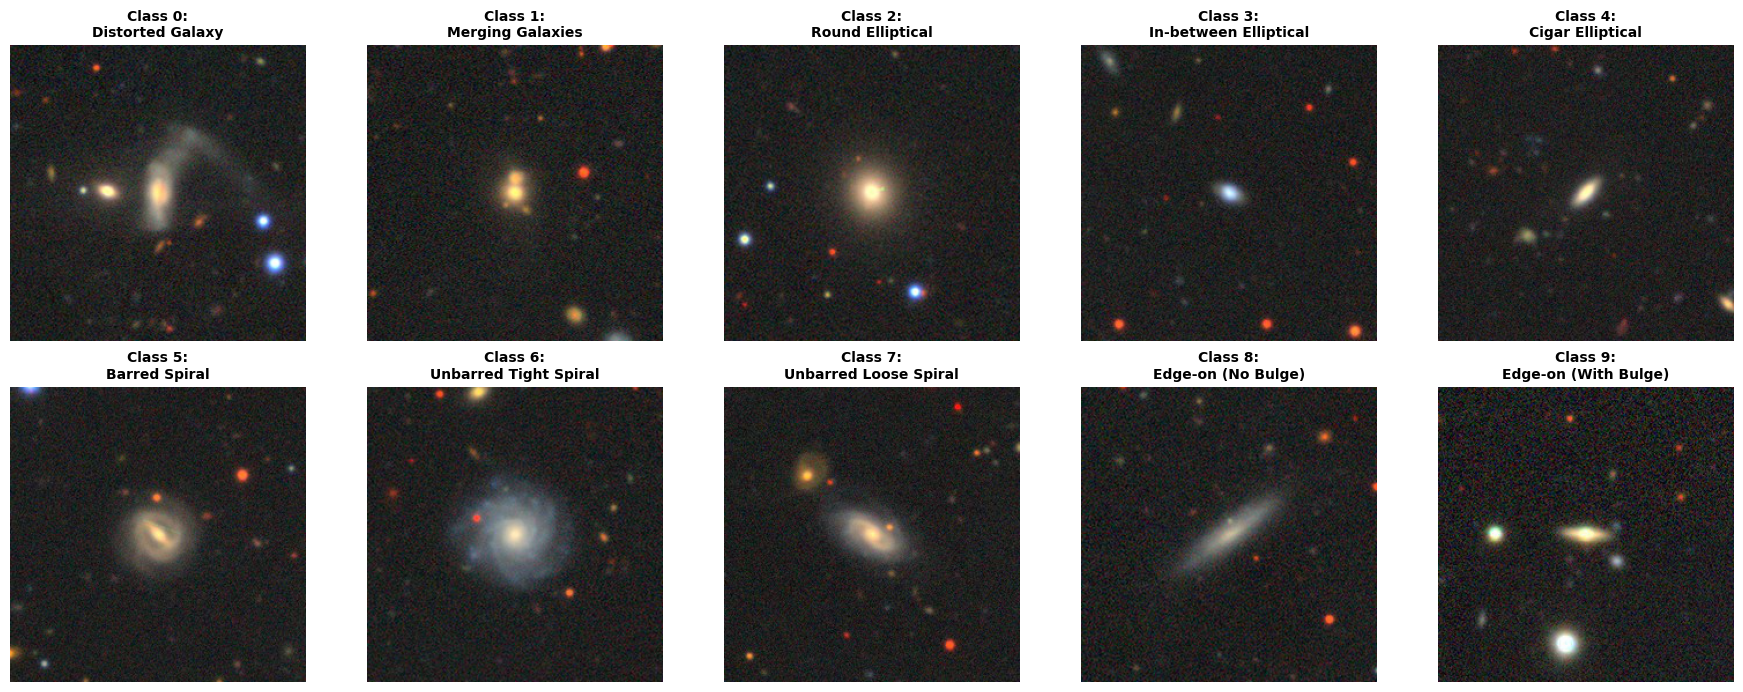

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Morphological class names mapping for Galaxy10 DECaLS
class_names = {
    0: "Distorted Galaxy",
    1: "Merging Galaxies",
    2: "Round Elliptical",
    3: "In-between Elliptical",
    4: "Cigar Elliptical",
    5: "Barred Spiral",
    6: "Unbarred Tight Spiral",
    7: "Unbarred Loose Spiral",
    8: "Edge-on (No Bulge)",
    9: "Edge-on (With Bulge)"
}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for class_id in range(10):
    idx = np.where(labels == class_id)[0][0]

    axes[class_id].imshow(images[idx])
    axes[class_id].set_title(f"Class {class_id}:\n{class_names[class_id]}", fontsize=10, fontweight='bold')
    axes[class_id].axis('off')

plt.tight_layout()
plt.show()

# Custom Class Inspection

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def inspect_class(class_id, num_samples=5):
    idx = np.where(labels == class_id)[0][:num_samples]

    cols = 5
    rows = int(np.ceil(num_samples / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))

    fig.suptitle(
            f"Galaxy Class {class_id}: {class_names[class_id]}",
            fontsize=16,
            fontweight='bold',
            y=1  # Positions title just above subplots
        )

    # Ensure axes is always a 1D array even for 1 row or 1 sample
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    for i in range(num_samples):
        axes[i].imshow(images[idx[i]])
        axes[i].set_title(f'Index: {idx[i]}', fontsize=11, fontweight='bold')
        axes[i].axis('off')

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Enter the class_id to inspect:5
Enter the number of samples to inspect:7


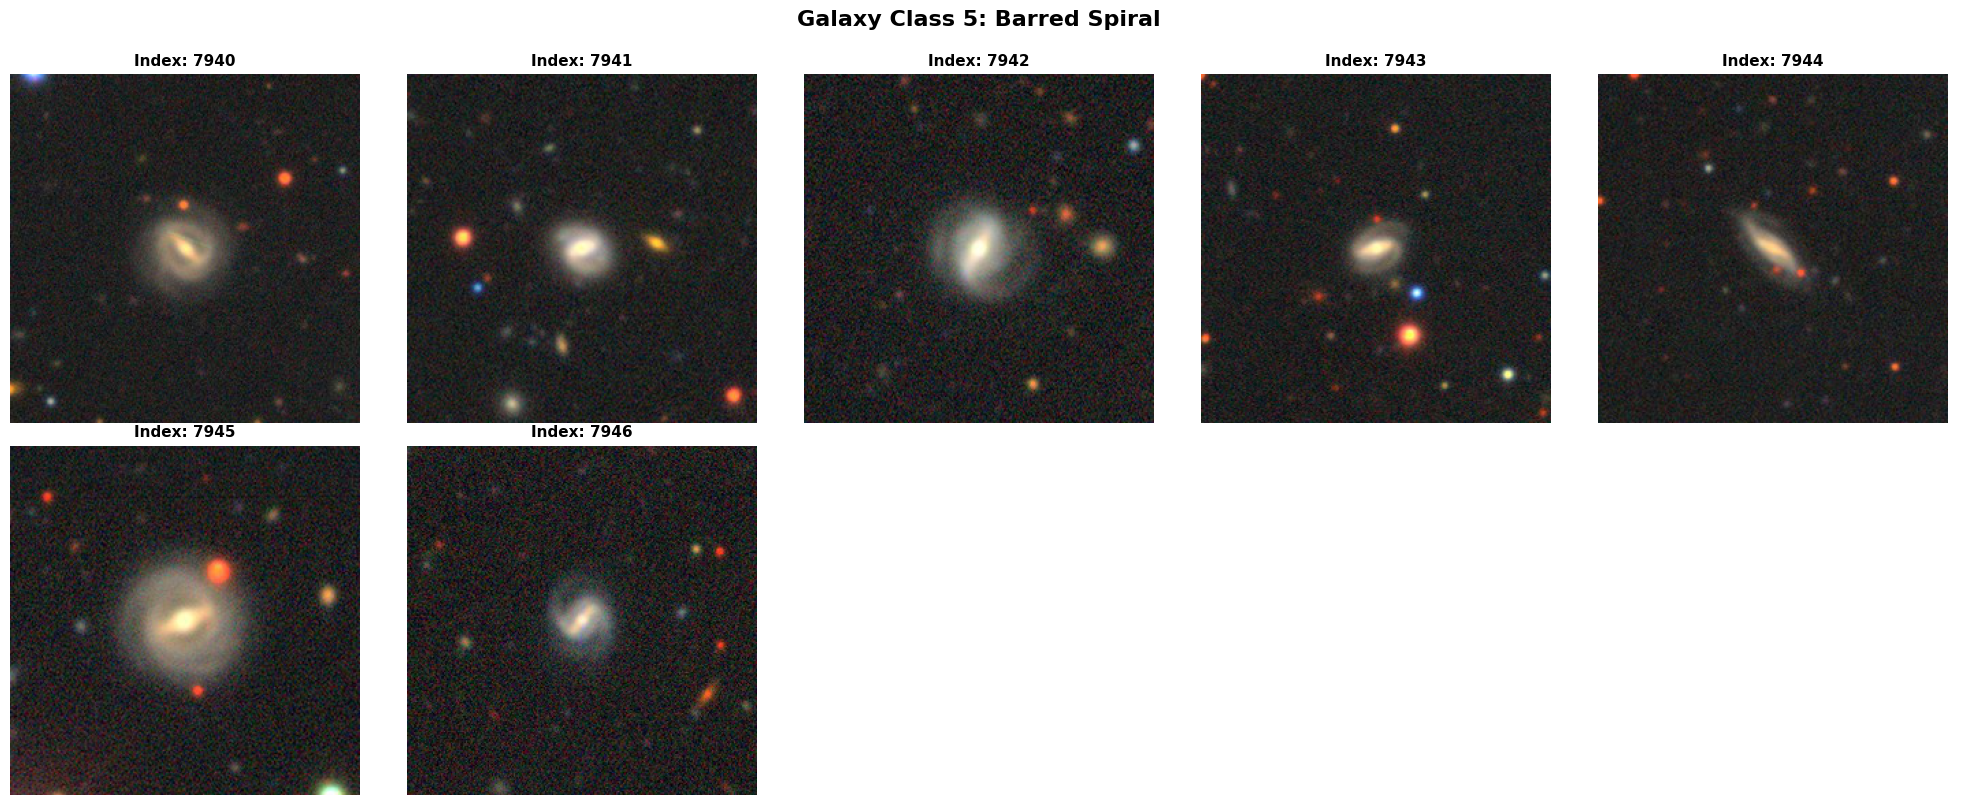

In [ ]:
class_id=int(input('Enter the class_id to inspect:'))
num_samples=int(input('Enter the number of samples to inspect:'))
inspect_class(class_id, num_samples)

# EDA using pandas

In [ ]:
import pandas as pd

df=pd.DataFrame({
    'image_index':np.arange(0,len(labels),1),
    'class_id':labels,
})

df['class_name']=df['class_id'].map(class_names)

In [ ]:
df.head()

,image_index,class_id,class_name
0,0,0,Distorted Galaxy
1,1,0,Distorted Galaxy
2,2,0,Distorted Galaxy
3,3,0,Distorted Galaxy
4,4,0,Distorted Galaxy


In [ ]:
df.isnull().sum()

,0
image_index,0
class_id,0
class_name,0


In [ ]:
pd.concat([
    df['class_name'].value_counts(),
    df['class_name'].value_counts(normalize=True)
],axis=1)


,count,proportion
class_name,,
Round Elliptical,2645,0.149132
Unbarred Loose Spiral,2628,0.148173
Barred Spiral,2043,0.115189
In-between Elliptical,2027,0.114287
Edge-on (With Bulge),1873,0.105604
Merging Galaxies,1853,0.104477
Unbarred Tight Spiral,1829,0.103124
Edge-on (No Bulge),1423,0.080232
Distorted Galaxy,1081,0.060949


# EDA using visualization

## 1. Class distribution

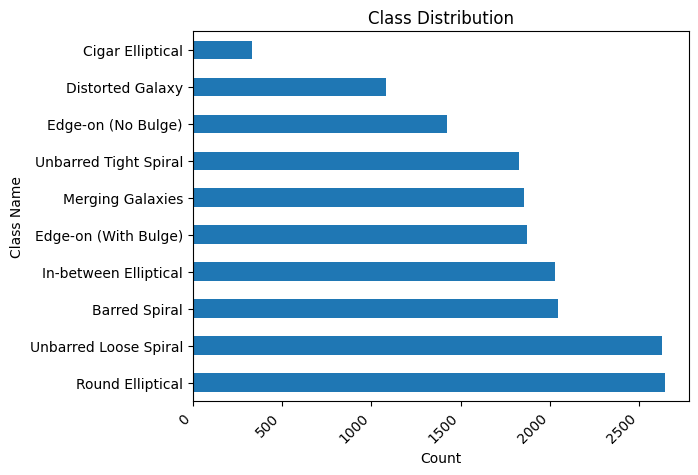

In [ ]:
df['class_name'].value_counts().plot(kind='barh')

plt.xticks(rotation=45,ha='right')
plt.xlabel('Count')
plt.ylabel('Class Name')
plt.title('Class Distribution')
plt.show()

## 2. Relative percentage

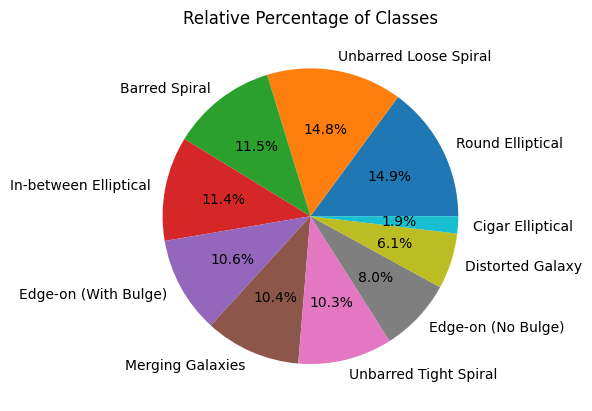

In [ ]:
df['class_name'].value_counts().plot(kind='pie',autopct='%0.1f%%')

plt.ylabel('')
plt.title('Relative Percentage of Classes')
plt.show()

# Splitting the data

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
indices=np.arange(len(images))

train_idx,val_idx,y_train,y_val=train_test_split(
    indices,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [5]:
print(f"Training set:   {len(train_idx)} samples")
print(f"Validation set: {len(val_idx)} samples")

Training set:   14188 samples
Validation set: 3548 samples


# Data Pipeline and Preprocessing

In [6]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size=32
target_size=(224,224)

In [7]:
def data_generator(indices,image_array,label_array):

  for idx in indices:
    yield image_array[idx].astype(np.float32),label_array[idx]

In [8]:
def preprocess(image,label):

  image=tf.image.resize(image,target_size)

  return image,label

In [9]:

def create_pipeline(indices, is_training=True):
    ds = tf.data.Dataset.from_generator(
        lambda: data_generator(indices, images, labels),
        output_signature=(
            tf.TensorSpec(shape=images.shape[1:], dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 1000))

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    if is_training:
      ds=ds.repeat()

    ds=ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_dataset = create_pipeline(train_idx, is_training=True)
val_dataset = create_pipeline(val_idx, is_training=False)

# Creating the Model

In [20]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0  # Switched to EfficientNetB0

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs, name='Galaxy10_EfficientNetB0')

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Galaxy10_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print('Model successfully compiled for training')

Model successfully compiled for training


In [22]:
from tensorflow.keras import callbacks

early_stopping=callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint=callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr=callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

cb_list=[early_stopping,model_checkpoint,reduce_lr]

# Model Training (Phase 1)



In [23]:
steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3882 - loss: 1.6857
Epoch 1: val_loss improved from None to 1.28834, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1345s 3s/step - accuracy: 0.4407 - loss: 1.5329 - val_accuracy: 0.5318 - val_loss: 1.2883 - learning_rate: 0.0010
Epoch 2/15
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5051 - loss: 1.3714
Epoch 2: val_loss improved from 1.28834 to 1.27927, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1318s 3s/step - accuracy: 0.5160 - loss: 1.3424 - val_accur

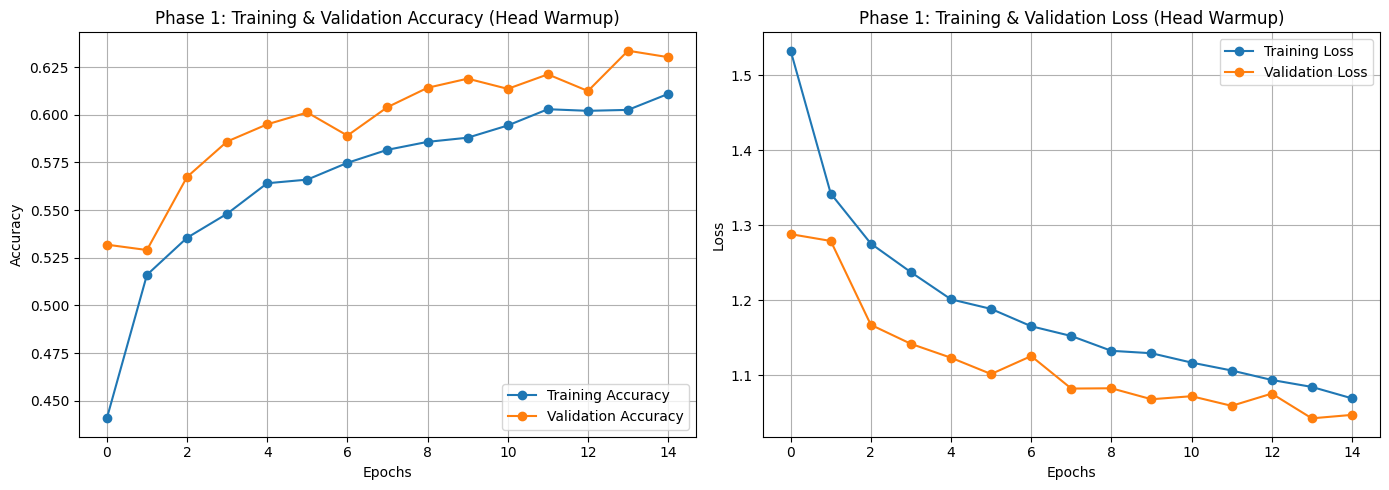

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot( history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 1: Training & Validation Accuracy (Head Warmup)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot( history.history['loss'], label='Training Loss', marker='o')
plt.plot( history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 1: Training & Validation Loss (Head Warmup)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/phase1_performance.png', bbox_inches='tight')
plt.show()

# Model Training (Phase 2)


In [ ]:
import tensorflow as tf

# Load Phase 1 saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras')

# Isolate base_model reference from loaded model
base_model = model.get_layer('efficientnetb0')

In [ ]:
# Unfreeze base model
base_model.trainable = True

# Keep lower layers frozen, unfreeze top ~40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# CRITICAL: Recompile with 1e-5 learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "Galaxy10_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 2,381,210 (9.08 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [ ]:
# Assuming Phase 1 ran for 10 epochs
phase1_epochs = 15
total_epochs = phase1_epochs + 12  # 22 total epochs

steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=total_epochs,
    initial_epoch=phase1_epochs,  # Continues log output from Epoch 11
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list
)

Epoch 16/27
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4229 - loss: 2.1146
Epoch 16: val_loss improved from None to 1.22881, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1_best.keras

Epoch 16: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1756s 4s/step - accuracy: 0.4592 - loss: 1.8005 - val_accuracy: 0.5792 - val_loss: 1.2288 - learning_rate: 1.0000e-05
Epoch 17/27
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5245 - loss: 1.3602
Epoch 17: val_loss improved from 1.22881 to 1.12440, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1_best.keras

Epoch 17: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1688s 4s/step - accuracy: 0.5

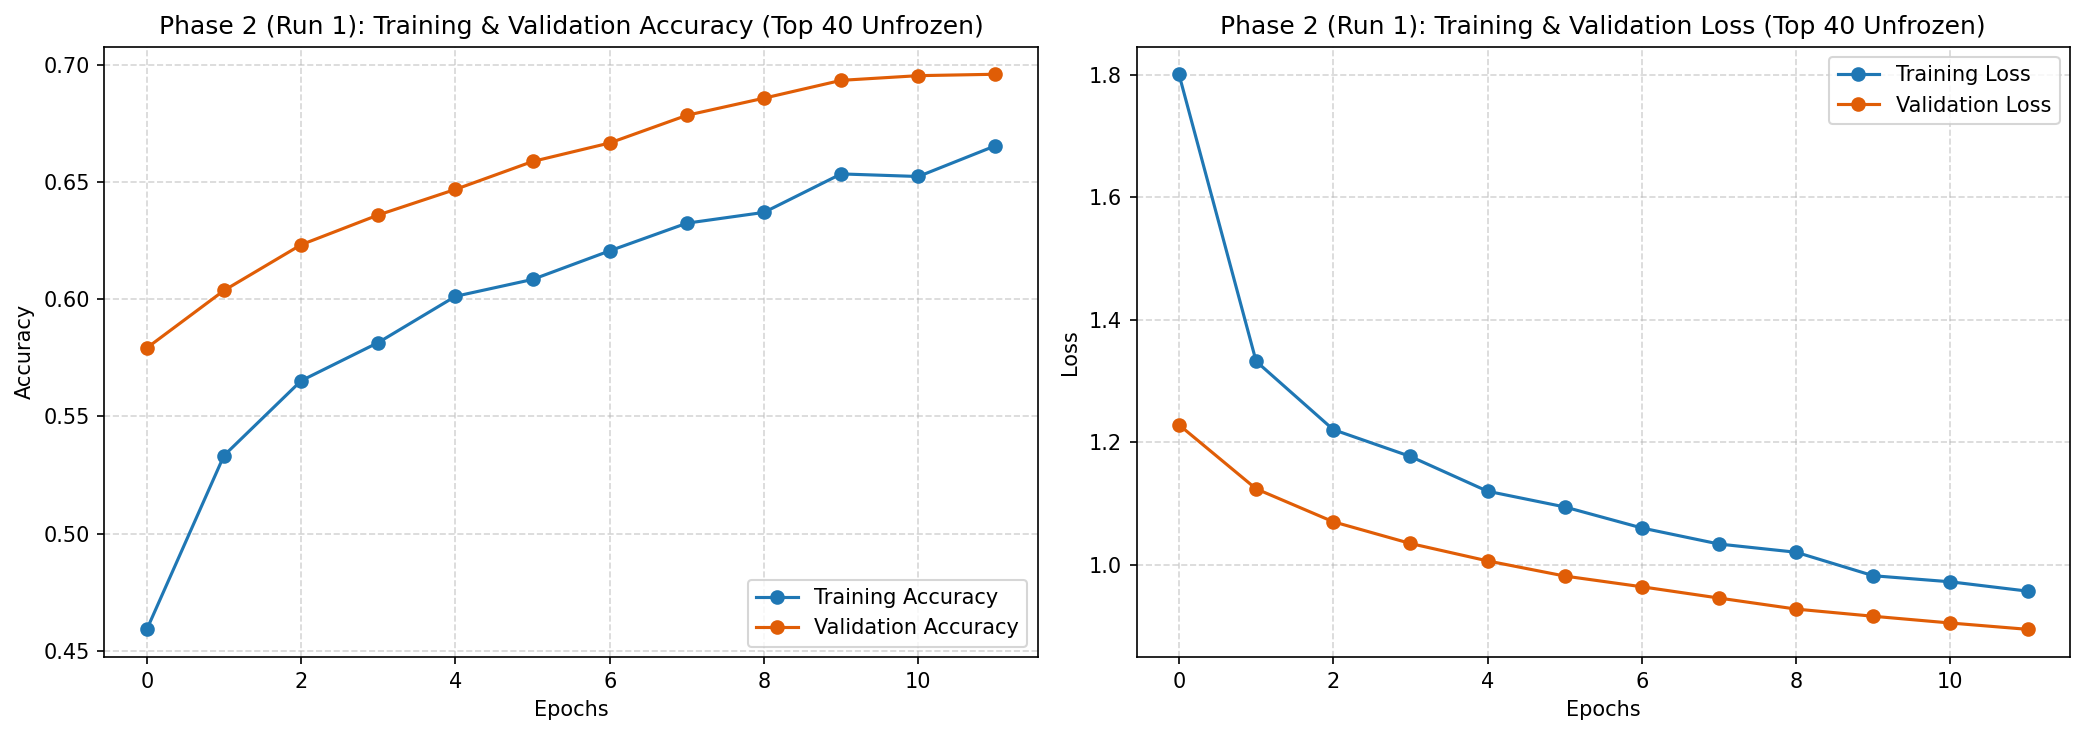

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase2.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot( history_phase2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 2: Training & Validation Accuracy (Top 40 Unfrozen)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot( history_phase2.history['loss'], label='Training Loss', marker='o')
plt.plot( history_phase2.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 2: Training & Validation Loss (Top 40 Unfrozen)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/phase2_run1_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Model Training (Phase 2 Run 2)

In [ ]:
import tensorflow as tf

# Load Phase 1 saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2.keras')

# Isolate base_model reference from loaded model
base_model = model.get_layer('efficientnetb0')

In [ ]:
# Continuation run: Epochs 28 through 37
steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

history_phase2_run2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=37,             # Extend total target to 37
    initial_epoch=27,      # Continues cleanly from today's best checkpoint
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list
)

Epoch 28/37
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6728 - loss: 0.9254
Epoch 28: val_loss improved from None to 0.88661, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras

Epoch 28: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1833s 4s/step - accuracy: 0.6726 - loss: 0.9352 - val_accuracy: 0.7007 - val_loss: 0.8866 - learning_rate: 1.0000e-05
Epoch 29/37
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6761 - loss: 0.9228
Epoch 29: val_loss improved from 0.88661 to 0.87770, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras

Epoch 29: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 1757s 4s/step - accuracy: 0.6

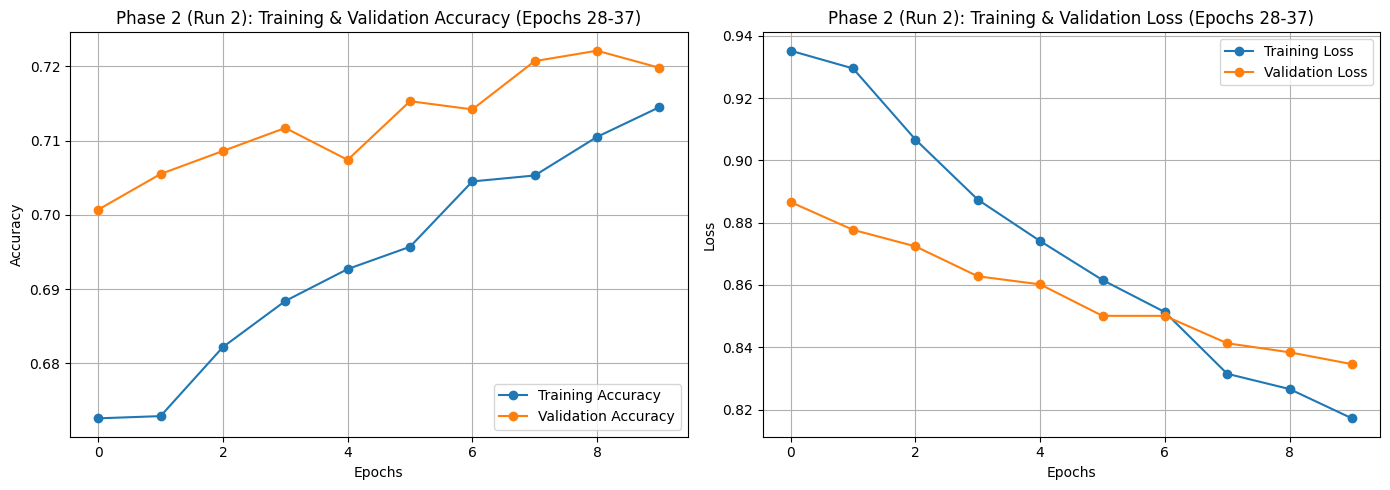

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase2_run2.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_phase2_run2.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 2 (Run 2): Training & Validation Accuracy (Epochs 28-37)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history_phase2_run2.history['loss'], label='Training Loss', marker='o')
plt.plot(history_phase2_run2.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 2 (Run 2): Training & Validation Loss (Epochs 28-37)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/phase2_run2_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Model Training (Phase 3 : Augmented)

In [ ]:
import tensorflow as tf

# Load Phase 1 saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras')

# Isolate base_model reference from loaded model
base_model = model.get_layer('efficientnetb0')

In [ ]:
steps_per_epoch = int(np.ceil(len(train_idx) / batch_size))
validation_steps = int(np.ceil(len(val_idx) / batch_size))

In [ ]:
from tensorflow.keras import models,layers

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=1.0),  # Full 360-degree rotational invariance
    layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
], name="spatial_augmentation")

train_dataset_augmented = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_phase3 = model.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=47,
    initial_epoch=37,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=cb_list
)

Epoch 38/47
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6555 - loss: 0.9918
Epoch 38: val_loss improved from None to 0.85941, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase3_augmented.keras

Epoch 38: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase3_augmented.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 2291s 5s/step - accuracy: 0.6594 - loss: 0.9784 - val_accuracy: 0.7046 - val_loss: 0.8594 - learning_rate: 5.0000e-06
Epoch 39/47
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6585 - loss: 0.9802
Epoch 39: val_loss improved from 0.85941 to 0.85512, saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase3_augmented.keras

Epoch 39: finished saving model to /content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase3_augmented.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 2235s 5s/

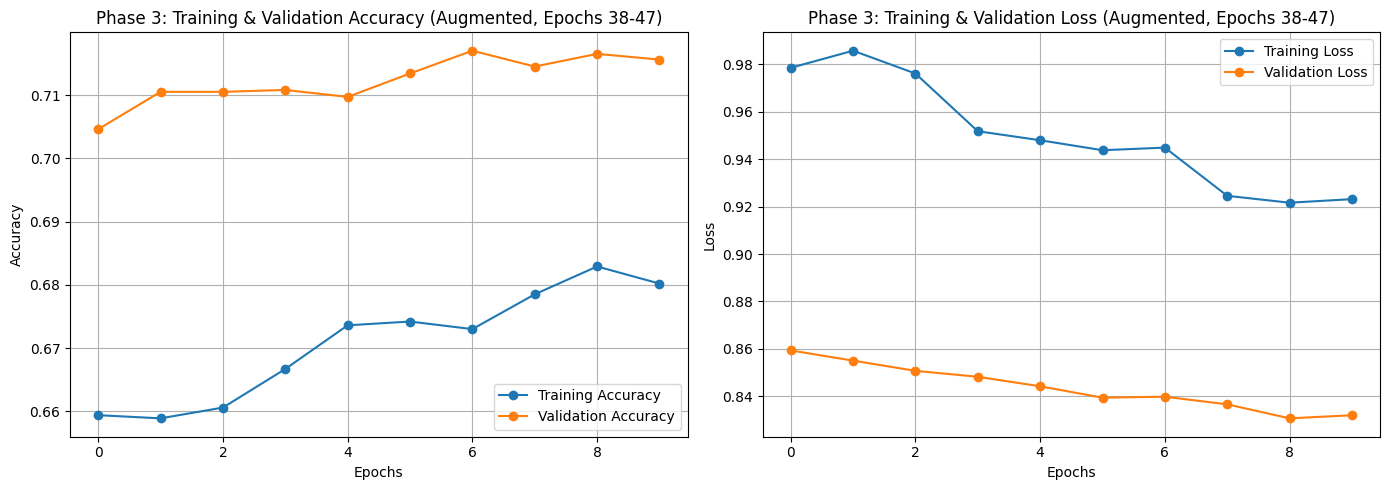

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase3.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_phase3.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Phase 3: Training & Validation Accuracy (Augmented, Epochs 38-47)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history_phase3.history['loss'], label='Training Loss', marker='o')
plt.plot(history_phase3.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Phase 3: Training & Validation Loss (Augmented, Epochs 38-47)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/phase3_augmented_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Master Plot depicting performance across all Epochs

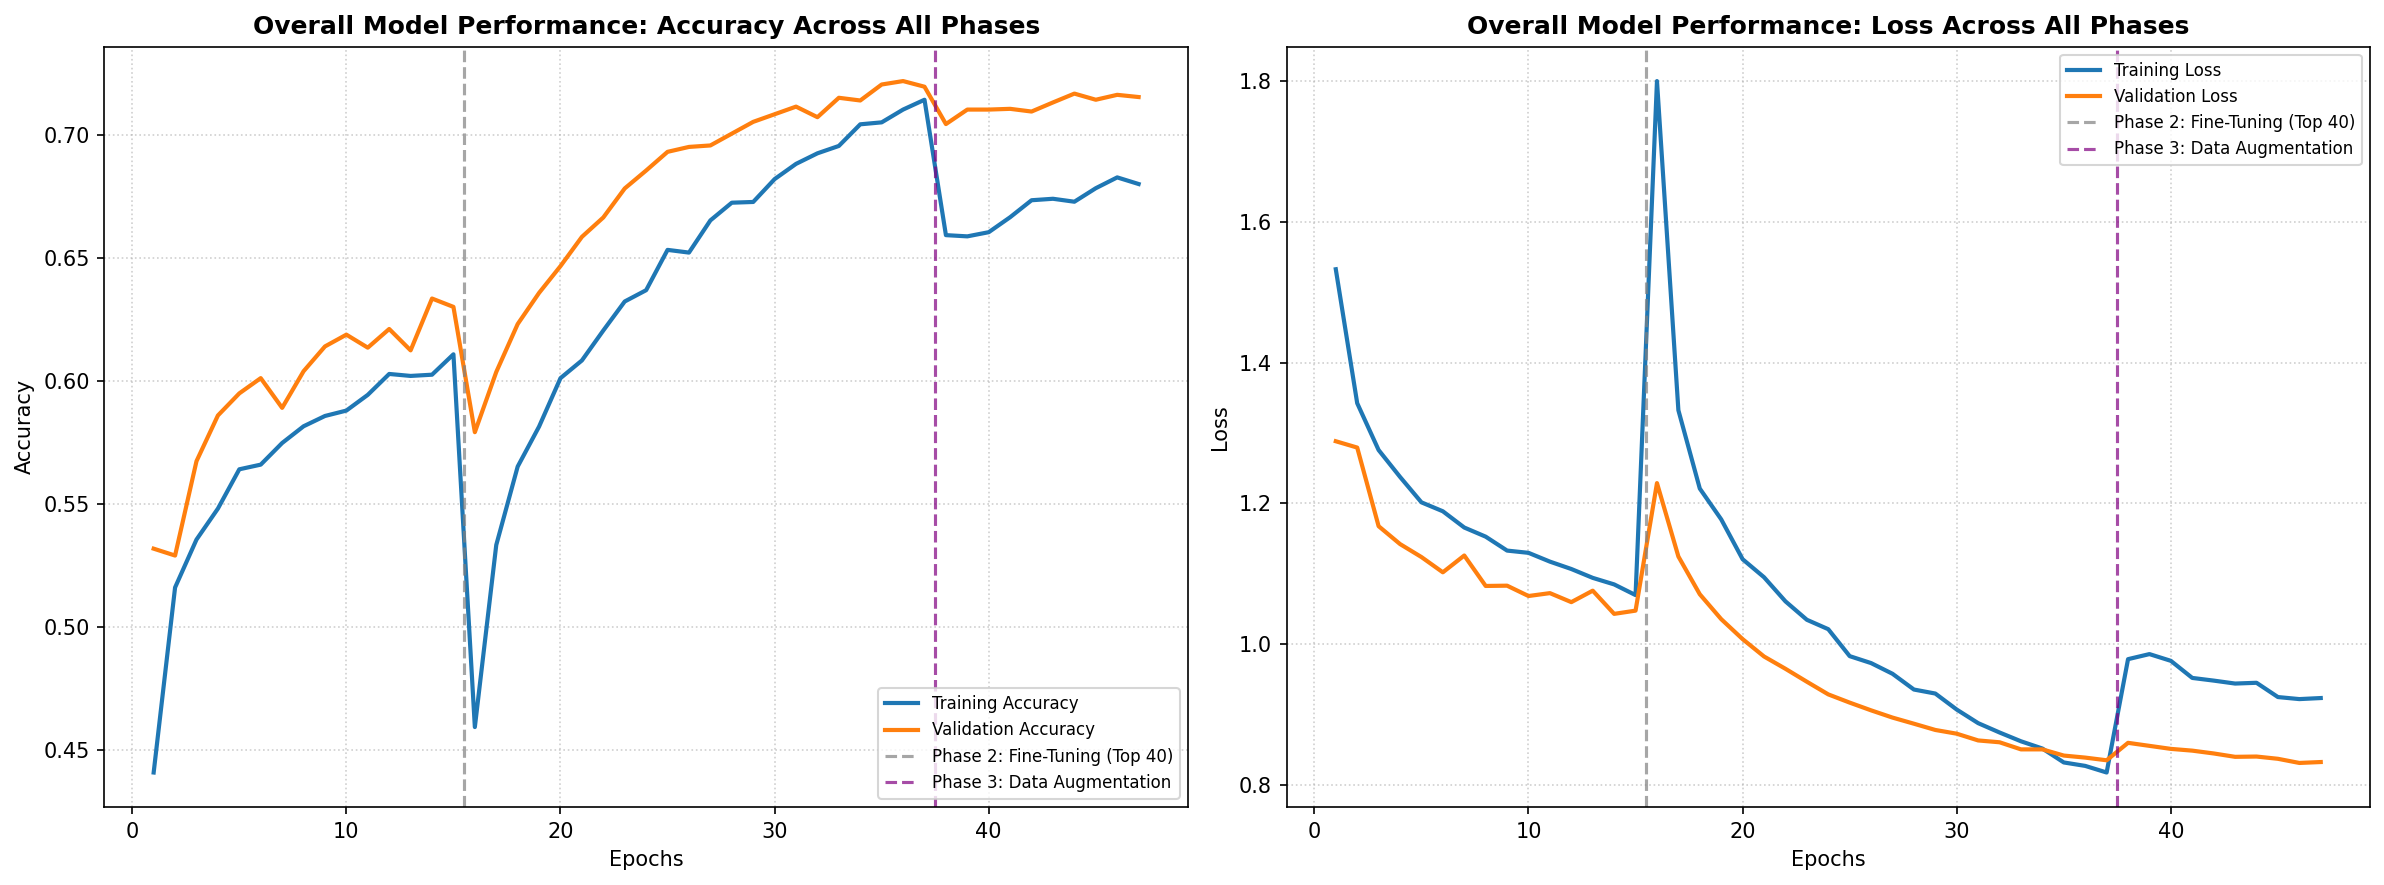

In [28]:
import matplotlib.pyplot as plt

# ==========================================
# MASTER PLOT: COMBINING ALL HISTORIES IN REAL-TIME
# ==========================================

# 1. Dynamically concatenate metric arrays from each phase's history object
full_accuracy = (
    history.history['accuracy'] +
    history_phase2_run1.history['accuracy'] +
    history_phase2_run2.history['accuracy'] +
    history_phase3.history['accuracy']
)

full_val_accuracy = (
    history.history['val_accuracy'] +
    history_phase2_run1.history['val_accuracy'] +
    history_phase2_run2.history['val_accuracy'] +
    history_phase3.history['val_accuracy']
)

full_loss = (
    history.history['loss'] +
    history_phase2_run1.history['loss'] +
    history_phase2_run2.history['loss'] +
    history_phase3.history['loss']
)

full_val_loss = (
    history.history['val_loss'] +
    history_phase2_run1.history['val_loss'] +
    history_phase2_run2.history['val_loss'] +
    history_phase3.history['val_loss']
)

# 2. Construct total epoch range dynamically
total_epochs = list(range(1, len(full_accuracy) + 1))

# Calculate phase boundary transition points dynamically
p1_end = len(history_phase1.history['accuracy'])
p2_end = p1_end + len(history_phase2_run1.history['accuracy']) + len(history_phase2_run2.history['accuracy'])

# ==========================================
# 3. PLOT MASTER TRAINING TRAJECTORY
# ==========================================
plt.figure(figsize=(16, 6), dpi=150)

# Plot 1: Accuracy Trajectory
plt.subplot(1, 2, 1)
plt.plot(total_epochs, full_accuracy, label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(total_epochs, full_val_accuracy, label='Validation Accuracy', color='#ff7f0e', linewidth=2)

# Dynamic Transition Boundaries
plt.axvline(x=p1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase 2: Fine-Tuning (Top 40)')
plt.axvline(x=p2_end + 0.5, color='purple', linestyle='--', alpha=0.7, label='Phase 3: Data Augmentation')

plt.title('Overall Model Performance: Accuracy Across All Phases', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Loss Trajectory
plt.subplot(1, 2, 2)
plt.plot(total_epochs, full_loss, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(total_epochs, full_val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)

# Dynamic Transition Boundaries
plt.axvline(x=p1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase 2: Fine-Tuning (Top 40)')
plt.axvline(x=p2_end + 0.5, color='purple', linestyle='--', alpha=0.7, label='Phase 3: Data Augmentation')

plt.title('Overall Model Performance: Loss Across All Phases', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/master_training_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Model Evaluation and Classification Report

In [25]:
import numpy as np
import tensorflow as tf

# Slice images and labels directly using your val_idx
x_val = images[val_idx]
y_val = labels[val_idx]

# Create an efficient TensorFlow Dataset pipeline
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (tf.image.resize(x, (224, 224)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Extract ground truth y_true once for evaluation
y_true = np.argmax(y_val, axis=1) if len(y_val.shape) > 1 and y_val.shape[-1] > 1 else y_val

## Phase 1

111/111 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.6336 - loss: 1.0428
Phase 1 Validation Accuracy: 63.36% | Validation Loss: 1.0428
111/111 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step
              precision    recall  f1-score   support

           0     0.5000    0.0926    0.1562       216
           1     0.5829    0.5499    0.5659       371
           2     0.6406    0.8053    0.7136       529
           3     0.6071    0.6296    0.6182       405
           4     0.5972    0.6418    0.6187        67
           5     0.6679    0.4279    0.5216       409
           6     0.5844    0.6530    0.6168       366
           7     0.4802    0.5989    0.5330       526
           8     0.8759    0.8697    0.8728       284
           9     0.8265    0.8640    0.8449       375

    accuracy                         0.6336      3548
   macro avg     0.6363    0.6133    0.6062      3548
weighted avg     0.6334    0.6336    0.6193      3548



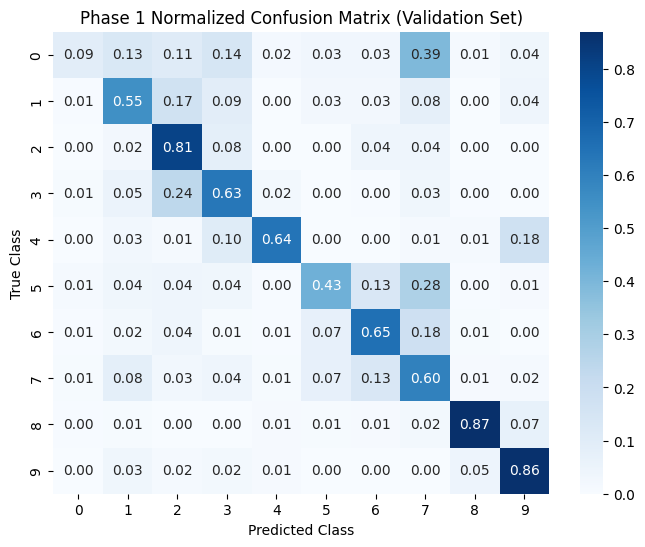

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model_p1 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase1.keras')
loss_p1, acc_p1 = model_p1.evaluate(val_ds)
print(f"Phase 1 Validation Accuracy: {acc_p1 * 100:.2f}% | Validation Loss: {loss_p1:.4f}")

preds_p1 = np.argmax(model_p1.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p1, digits=4))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p1, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 1 Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/cm_phase1.png', bbox_inches='tight', dpi=300)
plt.show()

## Phase 2 run 1

111/111 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.6959 - loss: 0.8953
Phase 2 (Run 1) Validation Accuracy: 69.59% | Validation Loss: 0.8953

111/111 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step
              precision    recall  f1-score   support

           0     0.5196    0.2454    0.3333       216
           1     0.6919    0.6900    0.6910       371
           2     0.7044    0.8828    0.7836       529
           3     0.7124    0.6790    0.6953       405
           4     0.5890    0.6418    0.6143        67
           5     0.7303    0.5428    0.6227       409
           6     0.6158    0.7049    0.6573       366
           7     0.5596    0.5798    0.5696       526
           8     0.8797    0.9014    0.8904       284
           9     0.8456    0.8907    0.8675       375

    accuracy                         0.6959      3548
   macro avg     0.6848    0.6759    0.6725      3548
weighted avg     0.6919    0.6959    0.6873      3548



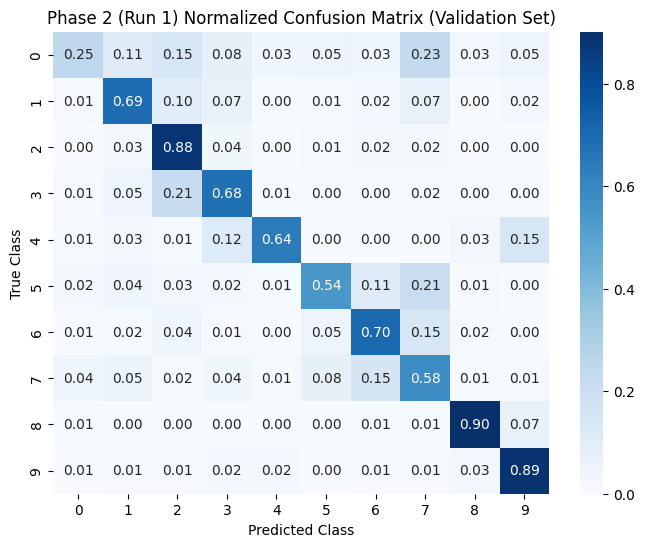

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

# Load model and evaluate on val_ds
model_p2_r1 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run1.keras')
loss_p2_r1, acc_p2_r1 = model_p2_r1.evaluate(val_ds)
print(f"Phase 2 (Run 1) Validation Accuracy: {acc_p2_r1 * 100:.2f}% | Validation Loss: {loss_p2_r1:.4f}\n")

# Get predictions and classification report
preds_p2_r1 = np.argmax(model_p2_r1.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p2_r1, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p2_r1, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 2 (Run 1) Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/cm_phase2_run1.png', bbox_inches='tight', dpi=300)
plt.show()

## Phase 2 run 2

111/111 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.7198 - loss: 0.8346
Phase 2 (Run 2) Validation Accuracy: 71.98% | Validation Loss: 0.8346

111/111 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step
              precision    recall  f1-score   support

           0     0.5044    0.2639    0.3465       216
           1     0.7008    0.7385    0.7192       371
           2     0.7440    0.8790    0.8059       529
           3     0.7639    0.7111    0.7366       405
           4     0.6184    0.7015    0.6573        67
           5     0.7241    0.6161    0.6658       409
           6     0.6368    0.6995    0.6667       366
           7     0.5951    0.5951    0.5951       526
           8     0.8889    0.9014    0.8951       284
           9     0.8607    0.9227    0.8906       375

    accuracy                         0.7198      3548
   macro avg     0.7037    0.7029    0.6979      3548
weighted avg     0.7133    0.7198    0.7125      3548



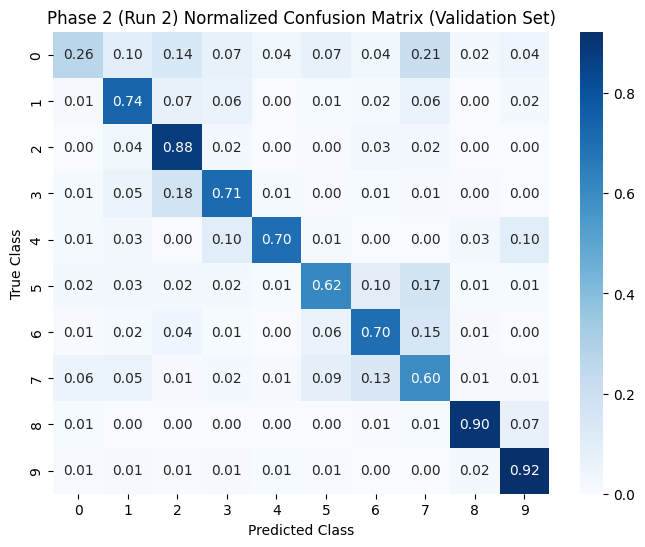

In [ ]:
# Load model and evaluate on val_ds
model_p2_r2 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras')
loss_p2_r2, acc_p2_r2 = model_p2_r2.evaluate(val_ds)
print(f"Phase 2 (Run 2) Validation Accuracy: {acc_p2_r2 * 100:.2f}% | Validation Loss: {loss_p2_r2:.4f}\n")

# Get predictions and classification report
preds_p2_r2 = np.argmax(model_p2_r2.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p2_r2, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p2_r2, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 2 (Run 2) Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/cm_phase2_run2.png', bbox_inches='tight', dpi=300)
plt.show()

## Phase 3

111/111 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.7165 - loss: 0.8308
Phase 3 Validation Accuracy: 71.65% | Validation Loss: 0.8308

111/111 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step
              precision    recall  f1-score   support

           0     0.4914    0.2639    0.3434       216
           1     0.6621    0.7871    0.7192       371
           2     0.7381    0.8790    0.8024       529
           3     0.8173    0.6519    0.7253       405
           4     0.7059    0.5373    0.6102        67
           5     0.7417    0.6528    0.6944       409
           6     0.6364    0.6885    0.6614       366
           7     0.5830    0.5741    0.5785       526
           8     0.8966    0.9155    0.9059       284
           9     0.8203    0.9253    0.8697       375

    accuracy                         0.7165      3548
   macro avg     0.7093    0.6875    0.6910      3548
weighted avg     0.7119    0.7165    0.7085      3548



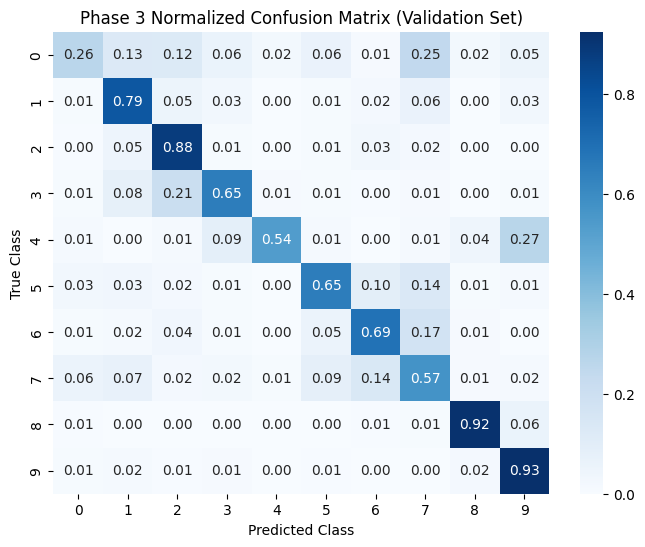

In [ ]:
# Load model and evaluate on val_ds
model_p3 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase3_augmented.keras')
loss_p3, acc_p3 = model_p3.evaluate(val_ds)
print(f"Phase 3 Validation Accuracy: {acc_p3 * 100:.2f}% | Validation Loss: {loss_p3:.4f}\n")

# Get predictions and classification report
preds_p3 = np.argmax(model_p3.predict(val_ds), axis=1)
print(classification_report(y_true, preds_p3, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, preds_p3, normalize='true'), annot=True, fmt='.2f', cmap='Blues')
plt.title('Phase 3 Normalized Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/visuals/cm_phase3.png', bbox_inches='tight', dpi=300)
plt.show()

# GRAD-CAM

In [16]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Get the nested base EfficientNetB0 model
    base_model = model.get_layer("efficientnetb0")

    # 2. Build a model that outputs base model's last conv layer output AND its final output
    last_conv_layer = base_model.get_layer("top_conv")
    conv_model = tf.keras.models.Model(
        inputs=[base_model.inputs],
        outputs=[last_conv_layer.output, base_model.output],
    )

    # 3. Record operations on tape
    with tf.GradientTape() as tape:
        # Pass image through base conv model
        conv_outputs, base_outputs = conv_model([img_array])

        # Pass base output through your top classification head layers
        x = model.get_layer("global_average_pooling2d_1")(base_outputs)
        x = model.get_layer("dense_2")(x)
        x = model.get_layer("dropout_1")(x)
        preds = model.get_layer("dense_3")(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Compute gradients of predicted class w.r.t last conv layer
    grads = tape.gradient(class_channel, conv_outputs)

    # 5. Pool gradients across channels
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Weight feature map channels by importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(heatmap, image_path, alpha=0.4):
    # Load original image
    img = cv2.imread(image_path)

    # Resize heatmap to match original image dimensions
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB colors (JET color map)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Superimpose heatmap onto original image
    superimposed_img = heatmap_colored * alpha + img
    return np.uint8(np.clip(superimposed_img, 0, 255))

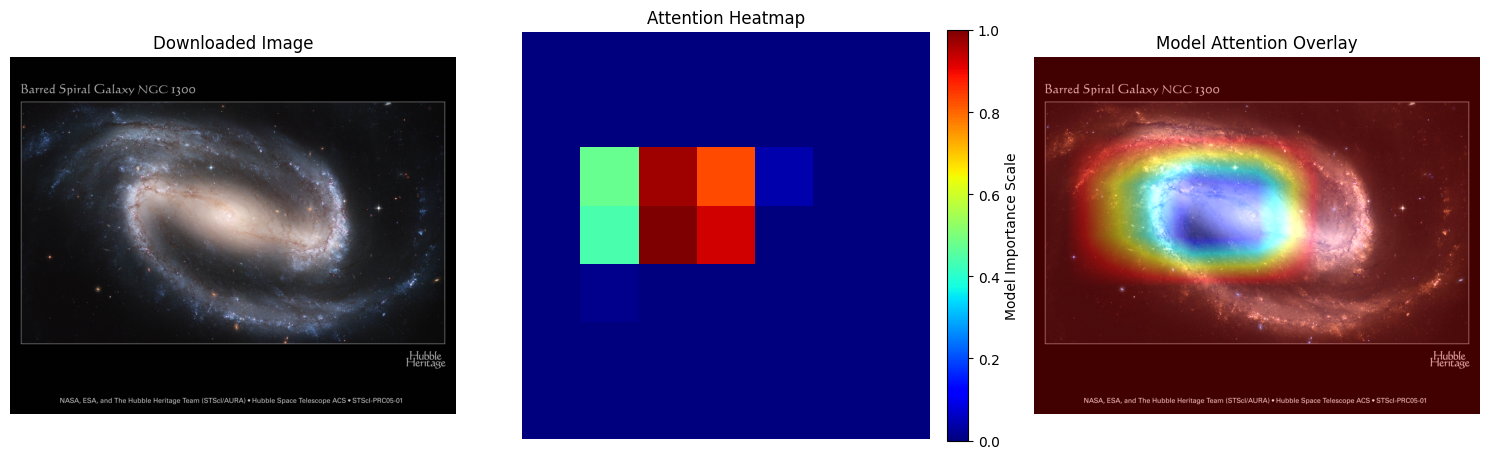

In [19]:
import urllib.request
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Download image from web URL
url = "https://assets.science.nasa.gov/content/dam/science/missions/hubble/releases/2005/01/STScI-01EVT8DP1YM9FYPF0Y33VY7ANB.tif/jcr:content/renditions/3000x2400.jpg"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img_bgr = cv2.imdecode(arr, -1)

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras"
)

# Save locally to pass to overlay_heatmap
local_path = "downloaded_galaxy.jpg"
cv2.imwrite(local_path, img_bgr)

# 2. Convert & Resize
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))

# 3. Create Tensor & Preprocess
img_tensor = np.expand_dims(img_resized, axis=0)
# img_tensor = img_tensor / 255.0  # Apply if used during training

# 4. Run Grad-CAM
heatmap = make_gradcam_heatmap(img_array=img_tensor, model=model)

# 5. Overlay Heatmap onto Original Image
overlay = overlay_heatmap(heatmap=heatmap, image_path=local_path, alpha=0.5)

# 6. Display with Color Bar
plt.figure(figsize=(15, 5))

# Subplot 1: Raw Original Image
plt.subplot(1, 3, 1)
plt.title("Downloaded Image")
plt.imshow(img_rgb)
plt.axis("off")

# Subplot 2: Activation Heatmap with Colorbar
plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
im = plt.imshow(heatmap, cmap="jet", vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Model Importance Scale")
plt.axis("off")

# Subplot 3: Grad-CAM Overlay
plt.subplot(1, 3, 3)
plt.title("Model Attention Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()